# Chapter 5: Practical implementation of the Perceptron
For the implemented class, see `py_perceptron.py` in the `py_perceptron` folder.

In [8]:
import sys
import os

# Ensure import from parent directory works
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../../')))

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime
import pickle
from sklearn.model_selection import train_test_split
from py_perceptron import PyPerceptron

In [10]:
def heaviside_step(x):
    # Heaviside step function
    return 1 if x >= 0 else 0

In [11]:
REASON_MAP = { 
        "Fitting": 0, 
        "Holes": 1, 
        "Zipper": 3, 
        "Smell": 4, 
        "Missing pieces": 5, 
        "Wrong style": 6, 
        "Price difference": 7, 
        "Early delivery": 8, 
        "Not ordered": 9, 
        "Stains": 10, 
        "Late delivery": 11, 
        "Color / Print": 12, 
        "Double delivery": 13,
        "Sew fault": 14, 
        "Wrong assortment": 15, 
        "Fabric / Woven fault ": 16, 
        "Size / Length": 17, 
        "Others": 18, 
        "Buttons": 19 ,
        "NO REASON": 20,
    }

### Data import and preprocessing

In [12]:
csv_data = pd.read_csv('../../data/prod_claims_2024-09-15_2024-09-21.csv')
print(csv_data.head())

# Change labels: If 0, keep as 0, if 1 or above, change to 1 (binary classification)
csv_data['label'] = csv_data['handling.name'].apply(lambda x: 0 if x == 'Rejected' else 1)

# Map reason string to number
csv_data['reason'] = csv_data['reason.name'].map(REASON_MAP)
csv_data['reason'] = csv_data['reason'].fillna(20)  # Fill NaN with 20 (NO REASON)

# Remove all where wholesale price is 0
csv_data = csv_data[csv_data['wholesale_price'] != 0]
# Remove all where quantity is 0
csv_data = csv_data[csv_data['quantity'] != 0]

# Remove top and bottom 1% of wholesale price and quantity
csv_data = csv_data[csv_data['wholesale_price'].between(csv_data['wholesale_price'].quantile(0.01), csv_data['wholesale_price'].quantile(0.99))]
csv_data = csv_data[csv_data['quantity'].between(csv_data['quantity'].quantile(0.1), csv_data['quantity'].quantile(0.9))]

# Sample a small percentage of accepted claims to balance the dataset
csv_data_accepted_cut = csv_data[csv_data['label'] == 1].sample(frac=0.015, random_state=42)
csv_data_rejected_cut = csv_data[csv_data['label'] == 0].sample(frac=0.6, random_state=42)
csv_data = pd.concat([csv_data_accepted_cut, csv_data_rejected_cut], ignore_index=True)

# Find out which features are most important (rejected or accepted)
csv_data_accepted = csv_data[csv_data['label'] == 1]
csv_data_rejected = csv_data[csv_data['label'] == 0]


# Split data into features and labels
X = csv_data.drop(columns=['handling.name', 'label'])
y = csv_data['label']

# Identify 3 features to use (for simplicity)
X = X[['number', 'reason', 'quantity', 'has_attachment']] # wholesale_price
print(f"Rejected X: {X[csv_data['label'] == 0]}")
X = X[['reason', 'quantity', 'has_attachment']]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Convert to numpy arrays
X_train = np.array(X_train)
X_test = np.array(X_test)
y_train = np.array(y_train)
y_test = np.array(y_test)

        number category  brand.u_number  wholesale_price market.u_name  \
0  PCLM0075571   defect              25              0.0         SPAIN   
1  PCLM0075570   defect              20             14.0         SPAIN   
2  PCLM0075569   defect              34              0.0         SPAIN   
3  PCLM0075569   defect              34              0.0         SPAIN   
4  PCLM0075569   defect              34              0.0         SPAIN   

   market.u_market_code  amount_of_boxes handling.name rejected_reason.reason  \
0                    19              1.0        Refund                    NaN   
1                    19              1.0        Refund                    NaN   
2                    19              1.0        Refund                    NaN   
3                    19              1.0        Refund                    NaN   
4                    19              1.0        Refund                    NaN   

        sys_created_on claim_record.number  cost_price currency  qua

### Plot the data

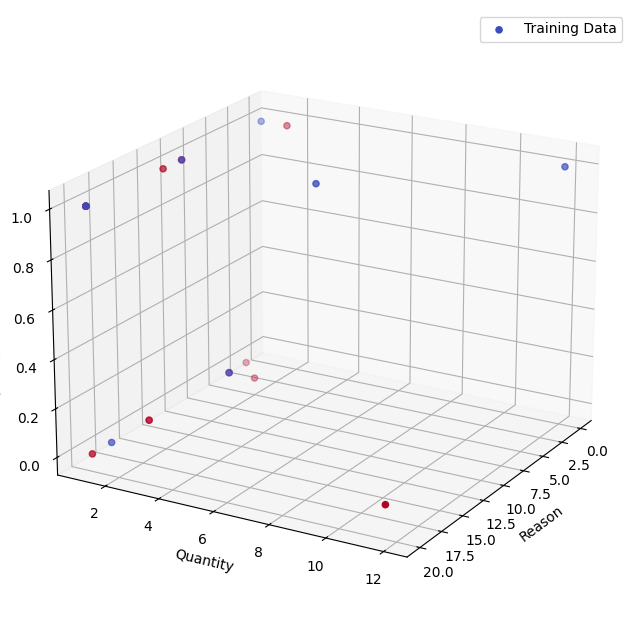

In [13]:
# Plot the 3D data
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_train[:, 0], X_train[:, 1], X_train[:, 2], c=y_train, cmap='coolwarm', marker='o', label='Training Data')
# ax.scatter(X_test[:, 0], X_test[:, 1], X_test[:, 2], c=y_test, cmap='coolwarm', marker='x', label='Testing Data')
ax.set_xlabel('Reason')
ax.set_ylabel('Quantity')
ax.set_zlabel('Has Attachment')
ax.set_axis_on()
ax.legend()
ax.view_init(elev=20, azim=30)  # Adjust the view angle
ax.grid(True)
plt.show()

### Instantiate the Perceptron class and train the model

X_train_with_bias: [[ 1.  0. 12.  1.]
 [ 1. 20.  1.  1.]
 [ 1. 18. 11.  0.]
 [ 1. 12.  1.  1.]
 [ 1. 10.  1.  1.]
 [ 1.  5.  1.  0.]
 [ 1. 20.  1.  0.]
 [ 1. 20.  1.  1.]
 [ 1.  3.  1.  0.]
 [ 1.  5.  1.  0.]
 [ 1.  5.  1.  0.]
 [ 1. 14.  1.  0.]
 [ 1. 20.  1.  1.]
 [ 1. 10.  6.  1.]
 [ 1.  1.  1.  1.]
 [ 1. 18.  1.  0.]
 [ 1. 20.  1.  1.]
 [ 1.  5.  2.  0.]
 [ 1. 10.  1.  1.]
 [ 1.  1.  2.  1.]
 [ 1.  5.  1.  0.]
 [ 1. 14.  1.  0.]]
Iteration limit reached. No convergence. 9999 epochs out of 10000 epochs.
Maximum epochs reached WITHOUT any final solution. Weights updated 12 times.
Final Weights: [-0.18  0.02  0.17 -0.8 ]
Confusion Matrix:
[[2 0]
 [2 2]]


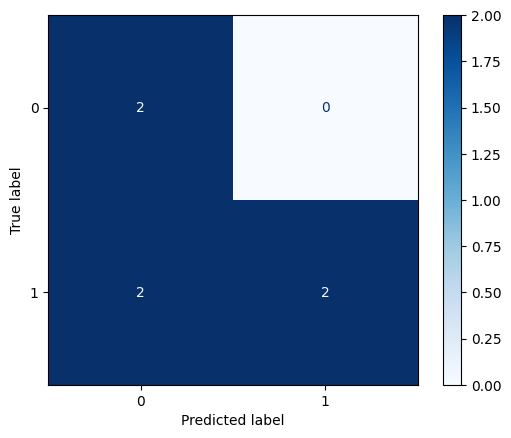

In [14]:
VERBOSE = False # toggle print logs from model

# Create a perceptron instance
perceptron = PyPerceptron(learning_rate=0.01, n_epochs=10000, activation_function=heaviside_step, init_weight_value=0.1, verbose=VERBOSE)
# perceptron = pickle.load(open('perceptron_model.pkl', 'rb')) # For loading a pre-trained model # For loading pre-trained model


# Fit the model
X_train_with_bias = perceptron.fit(X_train)
print(f"X_train_with_bias: {X_train_with_bias}")
# Train the model
perceptron.train(X_train_with_bias, y_train)
# Make predictions
y_pred = perceptron.predict(X_test)

# Evaluate
perceptron.score(y_pred, y_test)

# Calculate confusion matrix
confusion_matrix = perceptron.confusion_matrix(y_test, y_pred)
print(f"Confusion Matrix:\n{confusion_matrix}")
perceptron.plot_confusion_matrix(y_test, y_pred)



### Visualize the decision boundary

Final weights: [-0.18  0.02  0.17 -0.8 ]
Plane formula: 0 = -0.18000000000000002 + 0.01999999999975338 * x1 + 0.16999999999992108 * x2 + -0.8000000000000005 * x3
Decision Boundary: x3 = [[-1.25000000e-02 -7.44949495e-03 -2.39898990e-03 ...  4.77398990e-01
   4.82449495e-01  4.87500000e-01]
 [ 1.11111111e-02  1.61616162e-02  2.12121212e-02 ...  5.01010101e-01
   5.06060606e-01  5.11111111e-01]
 [ 3.47222222e-02  3.97727273e-02  4.48232323e-02 ...  5.24621212e-01
   5.29671717e-01  5.34722222e-01]
 ...
 [ 2.27777778e+00  2.28282828e+00  2.28787879e+00 ...  2.76767677e+00
   2.77272727e+00  2.77777778e+00]
 [ 2.30138889e+00  2.30643939e+00  2.31148990e+00 ...  2.79128788e+00
   2.79633838e+00  2.80138889e+00]
 [ 2.32500000e+00  2.33005051e+00  2.33510101e+00 ...  2.81489899e+00
   2.81994949e+00  2.82500000e+00]]
Decision Boundary: 0 = -0.18000000000000002 + 0.01999999999975338 * x1 + 0.16999999999992108 * x2 + -0.8000000000000005 * x3


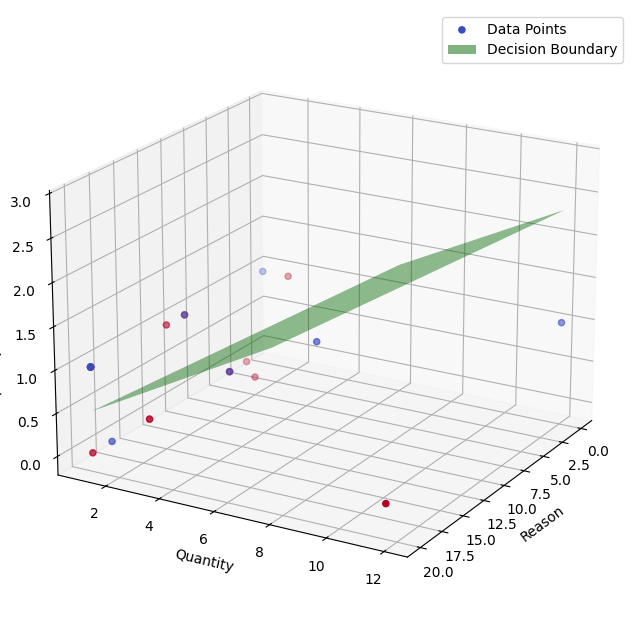

In [15]:
# Plot the decision boundary
def plot_decision_boundary_3d(weights, X, y):
    # Extract weights
    w0, w1, w2, w3 = weights

    # Create a meshgrid for 3D plotting
    # Get ranges for x1 and x2
    x1_min, x1_max = X[:, 0].min(), X[:, 0].max()
    x2_min, x2_max = X[:, 1].min(), X[:, 1].max()
    # Create grid of points
    x1_range = np.linspace(x1_min, x1_max, 100)
    x2_range = np.linspace(x2_min, x2_max, 100)
    X1, X2 = np.meshgrid(x1_range, x2_range)

    # Calculate decision boundary
    Z = -(w0 + w1 * X1 + w2 * X2) / w3

    # Formula (see theory and methodology)
    print(f"Decision Boundary: x3 = {-(w0 + w1 * X1 + w2 * X2) / w3}")
    print(f"Decision Boundary: 0 = {w0} + {w1} * x1 + {w2} * x2 + {w3} * x3")

    # Plot data points
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=y, cmap='coolwarm', marker='o', label='Data Points')
    ax.plot_surface(X1, X2, Z, alpha=0.5, color='green', label='Decision Boundary')
    ax.set_xlabel('Reason')
    ax.set_ylabel('Quantity')
    ax.set_zlabel('Has Attachment')
    ax.set_axis_on()
    ax.legend()
    ax.view_init(elev=20, azim=30)  # Adjust the view angle
    ax.grid(True)
    plt.show()


print(f"Final weights: {perceptron.get_weights()}")
print(f"Plane formula: 0 = {perceptron.get_weights()[0]} + {perceptron.get_weights()[1]} * x1 + {perceptron.get_weights()[2]} * x2 + {perceptron.get_weights()[3]} * x3")

plot_decision_boundary_3d(perceptron.get_weights(), X_train, y_train)

